In [1]:
import os
from tkinter import filedialog
import numpy as np
import pandas as pd
import tifffile
import matplotlib.pyplot as plt
from itertools import combinations

from cell_registration_revisions import CellReg

In [13]:
animal = 'astroF7'
N_sessions = 4  # Change to 2 if using only 2 sessions
scale_factor = 2

In [14]:

astro = CellReg(animal=animal, fov='FOV1', N_sessions=N_sessions, session_inds=None)
print(f"Animal: {astro.animal}, FOV: {astro.FOV}")
print(f"Base directory: {astro.base_directory}")
print(f"Metadata file: {astro.metadata_file}")

Animal: astroF7, FOV: FOV1
Base directory: /Users/suthardr/Desktop/Cell_Traces
Metadata file: /Users/suthardr/Desktop/Cell_Traces/Data_info_astro.csv


In [15]:

print("Loading 3D and shifted 2D footprints...")
footprints = astro.load_footprints_3D(affine_shifted=False)
reg_foots = astro.load_shifted_footprints_2D()

print("Loading cell registration matrix...")
reg_ind = astro.get_reg_ind()

Loading 3D and shifted 2D footprints...
Make sure these are in order: 
['hab' 'fc' 'cxtA' 'cxtB']
If theyre not in order, run load_footprints_3D again and set select sessions to True to put them in order
['/Users/suthardr/Desktop/Cell_Traces/CellReg/astroF7_FOV1/converted_maps/astroF7_hab_converted.mat', '/Users/suthardr/Desktop/Cell_Traces/CellReg/astroF7_FOV1/converted_maps/astroF7_fc_converted.mat', '/Users/suthardr/Desktop/Cell_Traces/CellReg/astroF7_FOV1/converted_maps/astroF7_cxta_converted.mat', '/Users/suthardr/Desktop/Cell_Traces/CellReg/astroF7_FOV1/converted_maps/astroF7_cxtb_converted.mat']
Loading cell registration matrix...
376 Unique cells detected in registration


In [16]:
def generate_footprint_images(footprints_3D, percentile=99):
    """
    Convert 3D binary footprints to summed 2D grayscale image for visualization.
    """
    max_images = []
    for session_footprints in footprints_3D:
        summed = session_footprints.sum(axis=0)
        vlim = np.percentile(summed, percentile)
        clipped = np.clip(summed, 0, vlim)
        max_images.append(clipped)
    return max_images


max_images = generate_footprint_images(footprints)

In [24]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.cm as cm

def plot_overlapping_footprints(astro, session_inds=[0, 1, 2, 3], alpha=0.3):
    """
    Plot registered cells' actual overlapping footprints across multiple sessions.
    Each session gets a different color; all matched cells are plotted on one canvas.

    Parameters:
    - astro: CellReg object with .footprints and .get_reg_ind()
    - session_inds: list of session indices to compare
    - alpha: transparency of overlay (default 0.3)
    """

    reg_ind = astro.get_reg_ind()
    footprints = astro.footprints
    n_sessions = len(session_inds)

    # Identify matched cells across all selected sessions
    matched_mask = np.all(reg_ind[:, session_inds] >= 0, axis=1)
    matched_cells = reg_ind[matched_mask][:, session_inds]

    # Get image shape from a single footprint mask
    sample_shape = footprints[session_inds[0]][0].shape
    composite = np.zeros((*sample_shape, 3))  # RGB composite image

    # Define a colormap or fixed colors per session
    session_colors = [
        (1, 0, 0),   # Red
        (0, 1, 0),   # Green
        (0, 0, 1),   # Blue
        (1, 1, 0)    # Yellow
    ]

    print(f"Plotting {matched_cells.shape[0]} matched cells across sessions: {session_inds}")

    for s_idx, session in enumerate(session_inds):
        color = session_colors[s_idx % len(session_colors)]
        for cell_idx in matched_cells[:, s_idx]:
            mask = footprints[session][cell_idx].astype(bool)
            for c in range(3):
                composite[:, :, c][mask] += color[c] * alpha

    # Normalize to max 1 for safe viewing
    composite = np.clip(composite, 0, 1)

    plt.figure(figsize=(8, 8))
    plt.imshow(composite)
    plt.title(f"Overlapping Matched Footprints - Sessions {session_inds}")
    plt.axis('off')
    plt.show()

In [23]:
plot_overlapping_footprints(astro, session_inds=[0, 1, 2, 3], alpha=0.4)


376 Unique cells detected in registration
Plotting 1 matched cells across sessions: [0, 1, 2, 3]


IndexError: boolean index did not match indexed array along dimension 0; dimension is 195 but corresponding boolean dimension is 196


--- Pair: Session 0 vs Session 1 ---
Registered cell count: 30
376 Unique cells detected in registration


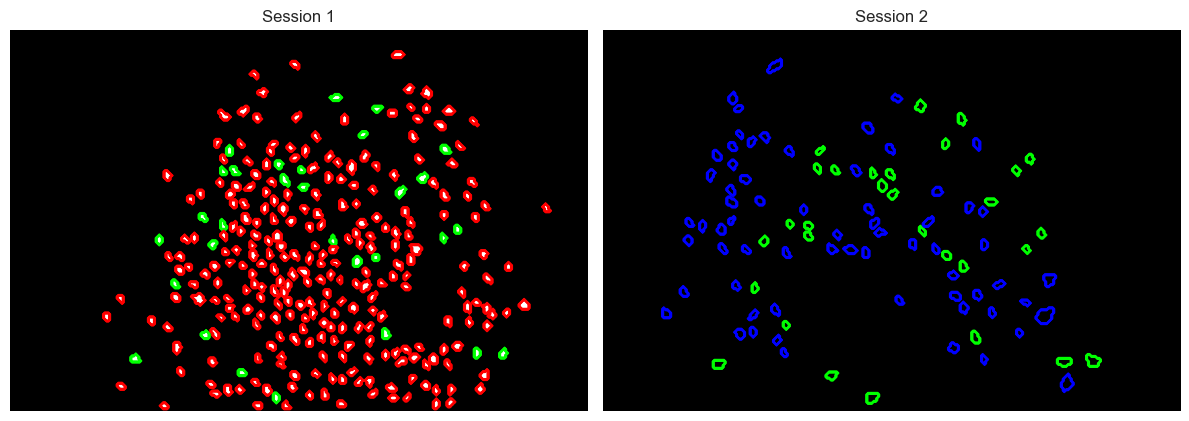


--- Pair: Session 0 vs Session 2 ---
Registered cell count: 5
376 Unique cells detected in registration


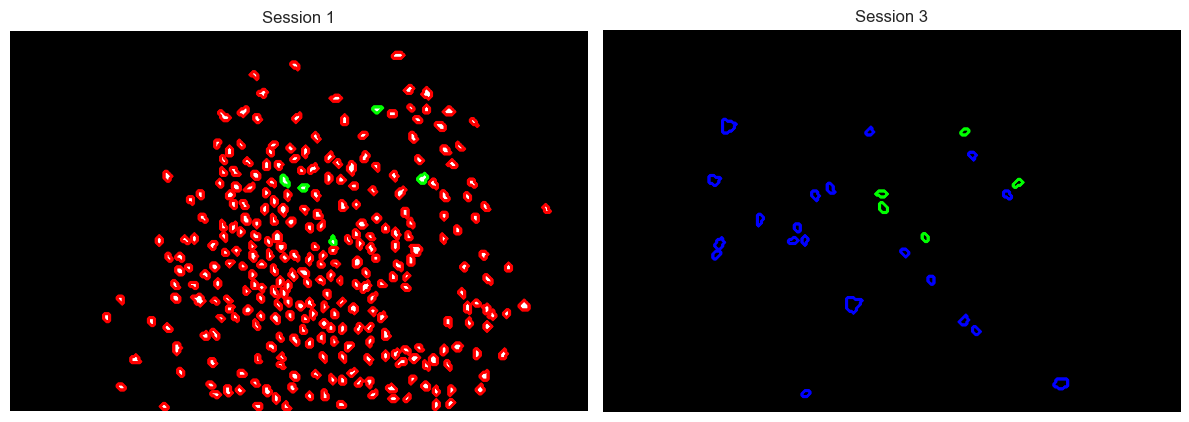


--- Pair: Session 0 vs Session 3 ---
Registered cell count: 3
376 Unique cells detected in registration


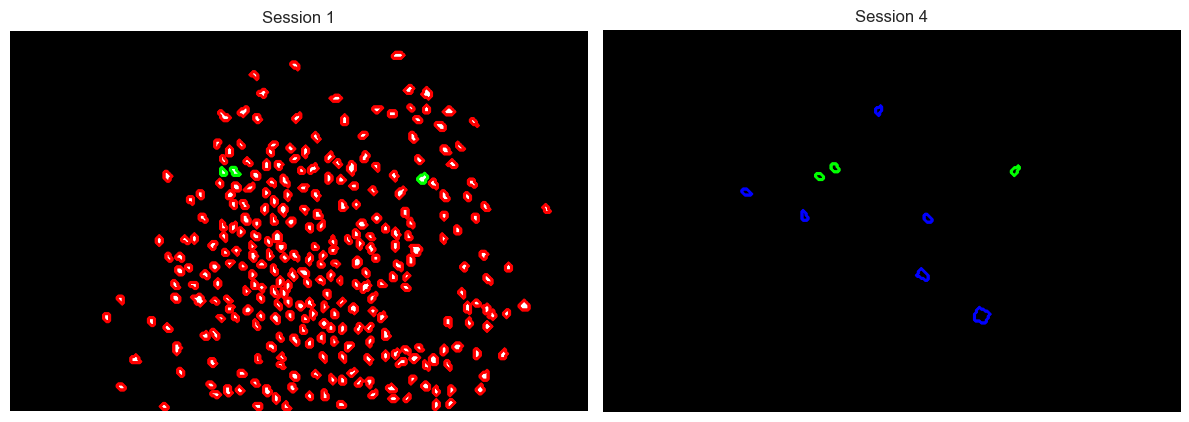


--- Pair: Session 1 vs Session 2 ---
Registered cell count: 11
376 Unique cells detected in registration


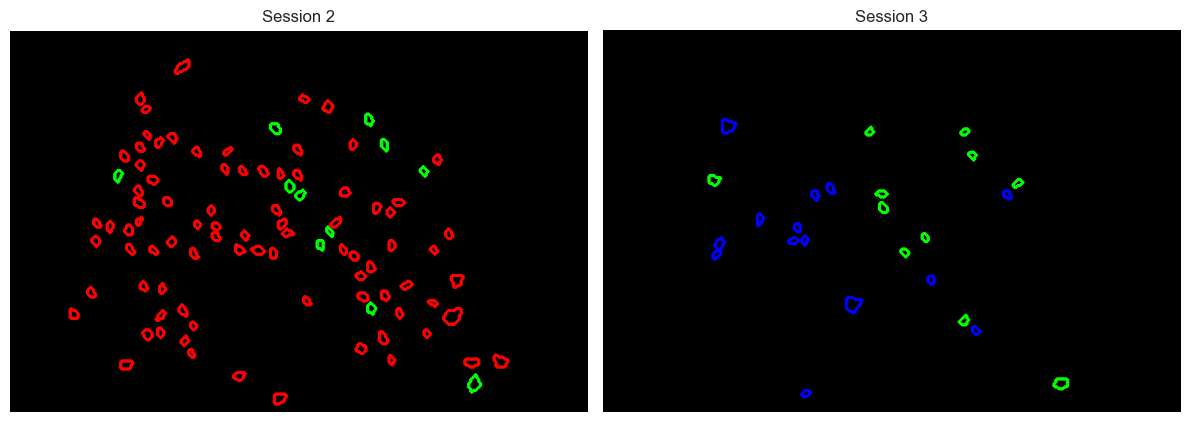


--- Pair: Session 1 vs Session 3 ---
Registered cell count: 6
376 Unique cells detected in registration


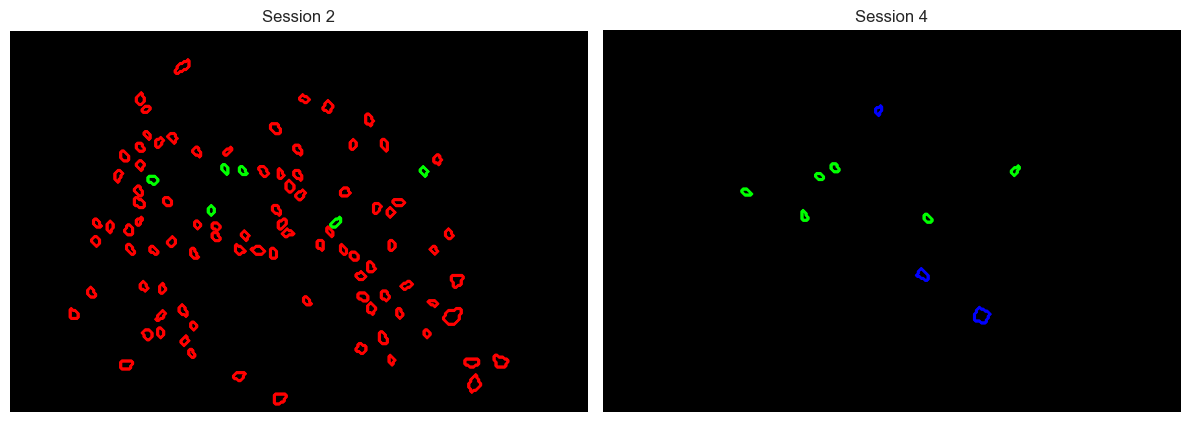


--- Pair: Session 2 vs Session 3 ---
Registered cell count: 1
376 Unique cells detected in registration


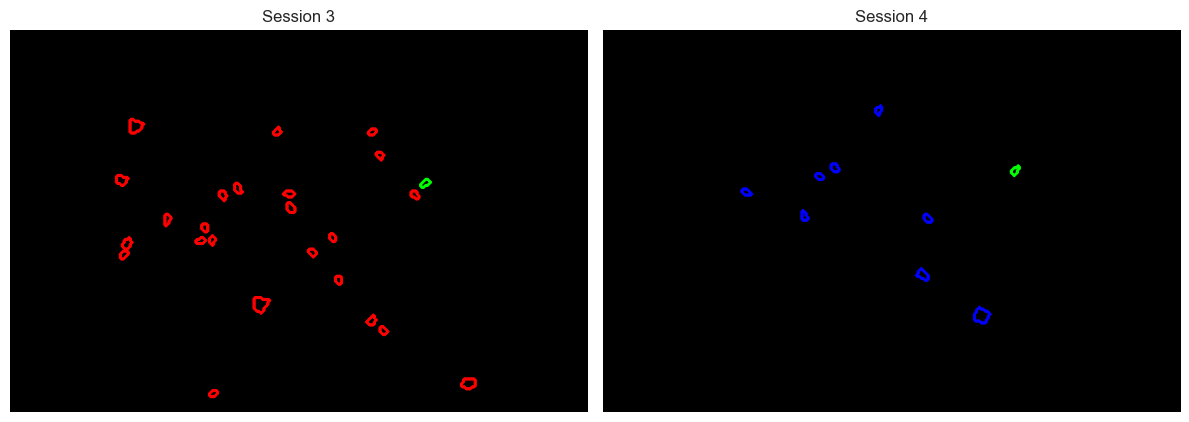

In [21]:

for s1, s2 in combinations(range(N_sessions), 2):
    print(f"\n--- Pair: Session {s1} vs Session {s2} ---")
    reg_cells = [
        reg_ind[:, s1][(reg_ind[:, s1] >= 0) & (reg_ind[:, s2] >= 0)],
        reg_ind[:, s2][(reg_ind[:, s1] >= 0) & (reg_ind[:, s2] >= 0)]
    ]
    print(f"Registered cell count: {len(reg_cells[0])}")

    # Plot for this pair
    plot_cell_reg_matplotlib(astro, session_inds=[s1, s2], image_list=max_images)

In [9]:

output_filename = f"{animal}_cell_reg.csv"
output_path = os.path.join('/Users/suthardr/Desktop/Cell_Traces/CellReg', output_filename)
np.savetxt(output_path, reg_ind, delimiter=",")
print(f"Saved registration matrix to: {output_path}")


Saved registration matrix to: /Users/suthardr/Desktop/Cell_Traces/CellReg/astroF6_cell_reg.csv
